In [37]:
import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd

from ggsc.composition import estimate_cell_frequencies

from figure_params import disease_colors, grade_colors

In [2]:
## Immune / stromal cells
adata_i = sc.read('../data/FL_scRNA_nonBcell_annotated.h5ad')

## Tumor cells
adata_t = sc.read('../data/FL_scRNA_Bcell_annotated.h5ad')

## Figure 1C - U-map of immune cells

/home/njharlen/anaconda3/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'cell_type_fine'}, xlabel='UMAP1', ylabel='UMAP2'>

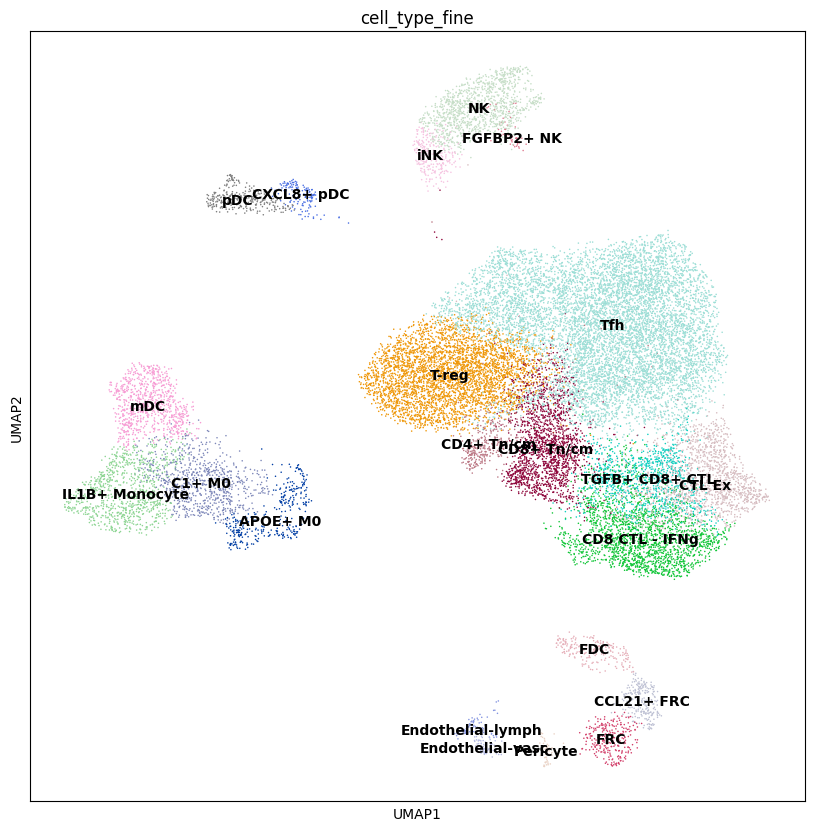

In [6]:
f,ax = plt.subplots(figsize=(10,10))
sc.pl.umap(adata_i,color='cell_type_fine',legend_loc = 'on data',ax=ax,show=False)

## Figure 1D - U-map of tumor cells

/home/njharlen/anaconda3/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'patient'}, xlabel='UMAP1', ylabel='UMAP2'>

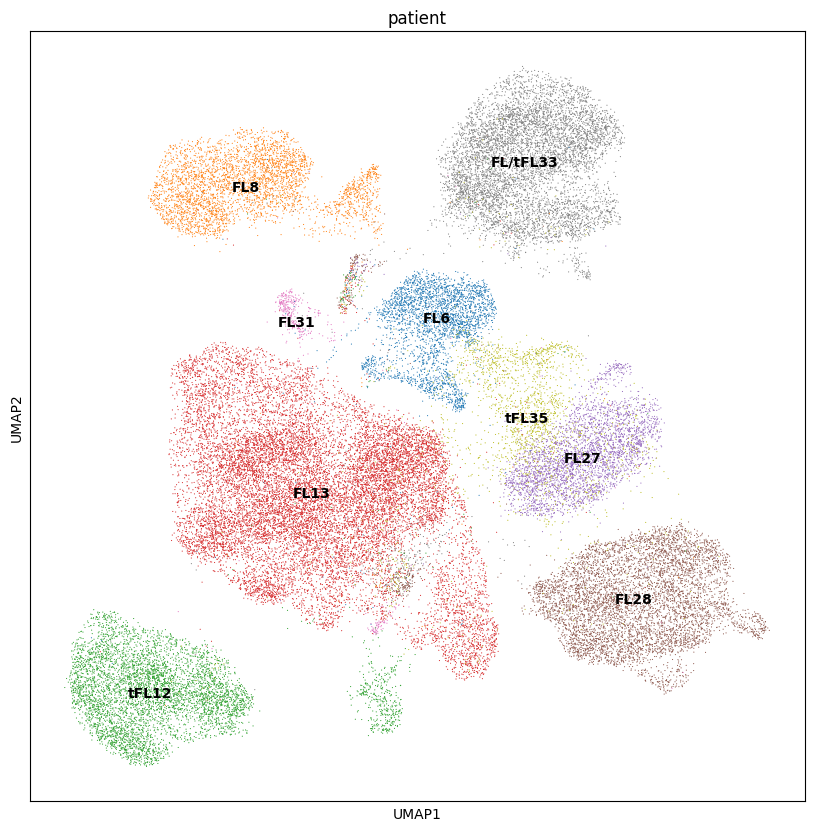

In [9]:
f,ax = plt.subplots(figsize=(10,10))

sc.pl.umap(adata_t,color='patient',legend_loc = 'on data',ax=ax,show=False)


## Figure 1E - cell type markers

/home/njharlen/anaconda3/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


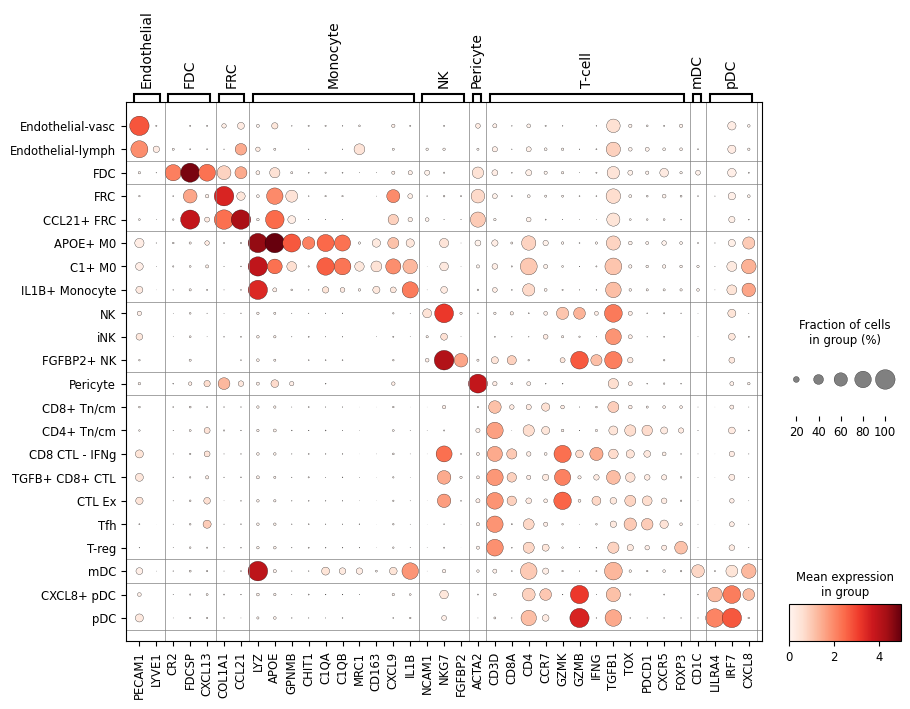

In [11]:
markers = {'Endothelial' : ['PECAM1','LYVE1'],
           'FDC' : ['CR2','FDCSP','CXCL13'],
           'FRC' : ['COL1A1','CCL21'],
           'Monocyte' : ['LYZ','APOE','GPNMB','CHIT1','C1QA','C1QB','MRC1','CD163','CXCL9','IL1B'],
           'NK' : ['NCAM1','NKG7','FGFBP2'],
           'Pericyte' : ['ACTA2'],
           'T-cell' : ['CD3D','CD8A','CD4','CCR7','GZMK','GZMB','IFNG','TGFB1','TOX','PDCD1','CXCR5','FOXP3'],
          'mDC' : ['CD1C'],
           'pDC' : ['LILRA4','IRF7','CXCL8']}

# Determine plotting order
ct_map = adata_i.obs[['cell_type_fine','cell_type_coarse']].drop_duplicates().sort_values('cell_type_coarse')
plot_order = list(adata_i.obs[['cell_type_fine','cell_type_coarse']].drop_duplicates().sort_values('cell_type_coarse')['cell_type_fine'].values)
adata_i.obs['cell_type_fine'] = pd.Categorical(adata_i.obs['cell_type_fine'],categories=plot_order)

g = sc.pl.dotplot(adata_i,markers,groupby='cell_type_fine',swap_axes=False,figsize=(10,7),show=False)

ct = 0
for k in markers.keys():
    ct +=len(markers[k])
    g['mainplot_ax'].axvline(ct,color='grey',linewidth=.5)

ct = 0
for cell_type,grp in ct_map.groupby('cell_type_coarse'):
    ct += grp.shape[0]
    g['mainplot_ax'].axhline(ct,color='grey',linewidth=.5)


## Figure 1F - Cell composition

### (top panel - time to transformation)

In [31]:
T = pd.read_excel('../data/scRNA_time_to_transformation.xlsx')

T['time_to_next_tFL'] = T['time_to_next_tFL'].fillna(T['time_to_next_tFL'].max()*2)
T = T.sort_values('time_to_next_tFL',ascending=False)

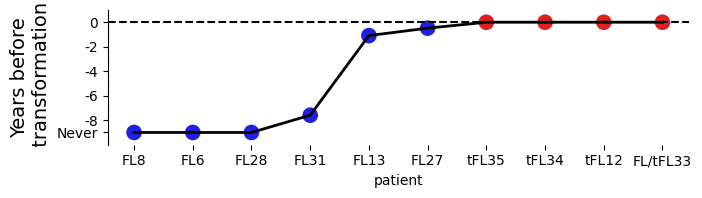

In [33]:
plt.figure(figsize=(7.5,1.75))
y=-1*np.minimum(365*9,T["time_to_next_tFL"])/365
sns.lineplot(x="patient",y=y,data=T,linewidth=2,color='k')
sns.scatterplot(x="patient",y=y,data=T,s=150,hue=T['disease'],palette=disease_colors)

plt.ylabel('Years before\n transformation',fontsize=14)

plt.ylim(-10,1)
plt.yticks([-9,-8,-6,-4,-2,0],['Never','-8','-6','-4','-2','0'])
plt.legend().remove()

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

plt.axhline(0,color='k',linestyle='--')

### Heatmap

In [78]:
df = estimate_cell_frequencies(adata_i,key='cell_type',pat_key='patient')
X = df.set_index(['cell_type','patient'])['frac'].unstack()
X=X[adata_i.obs['patient'].cat.categories]

low_idx = ~X.columns.str.contains('tFL')

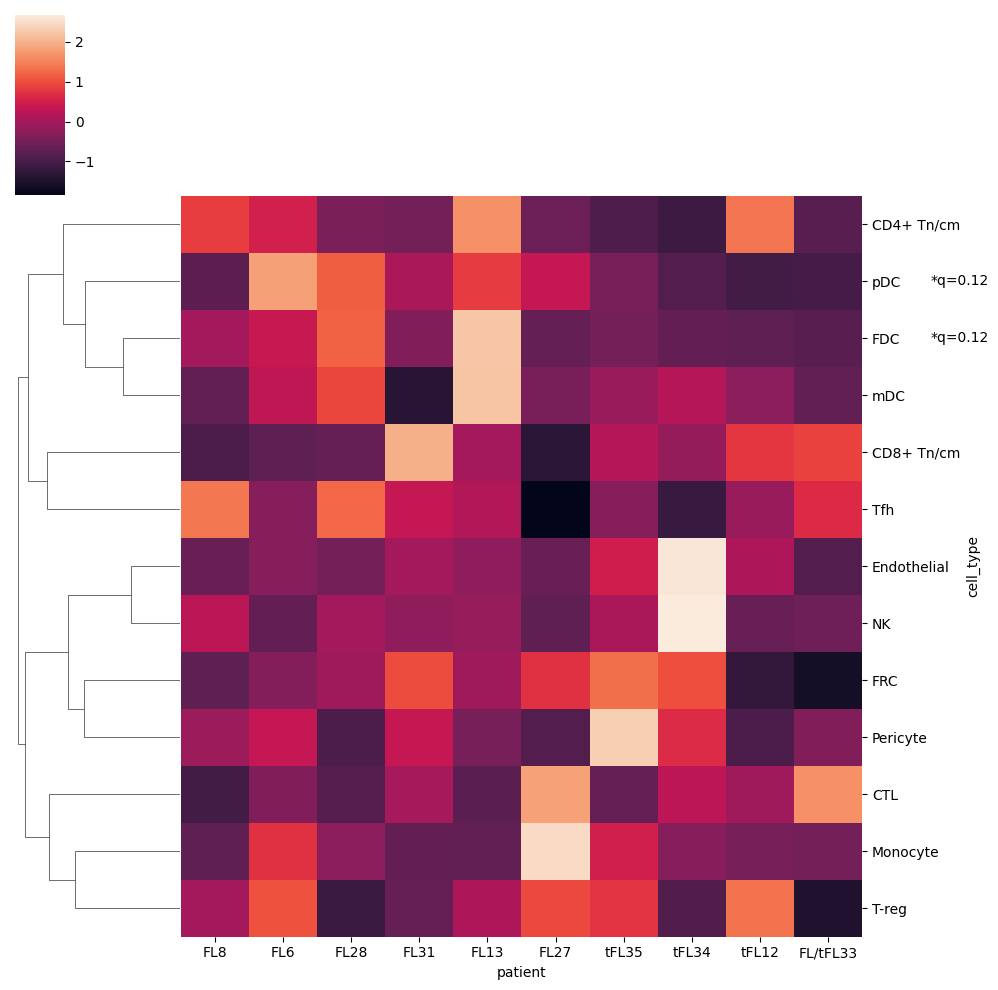

In [79]:
# Calculate ranksum
from scipy.stats import ranksums, ttest_ind
from statsmodels.stats.multitest import multipletests

pat_order = T['patient']

p = pd.Series([ranksums(X.loc[ct,low_idx],X.loc[ct,~low_idx])[1] \
               for ct in X.index],index=X.index).sort_values()
q = pd.Series(multipletests(p,method='fdr_bh')[1],index=p.index)

g = sns.clustermap(X[pat_order],z_score=0,col_cluster=False)



ylab = g.ax_heatmap.get_yticklabels()
i=0
for t in ylab:
    ct = t.get_text()
    if q[ct]<.25:
        sig = f'*q={q[ct]:.2f}'
        g.ax_heatmap.text(11,i+.5,sig,va='center',ha='left')
    i+=1
    